# Scaling terms — heteroskedastic regression and non-proportional survival

The default conditional transformation model adds covariates as an
*additive* shift,

$$
h(y \mid x_d) \;=\; h_0(y) + x_d^\top \beta,
$$

which gives proportional hazards (`Coxph`), proportional odds (`Colr`),
or a constant-variance Box-Cox.  When the conditional distribution
changes *spread* with the covariates — not just location — the shift
model is mis-specified.  mltpy's `scaling=` kwarg mirrors
R `tram::*(scale = ~x_s)` and multiplies the baseline by a strictly
positive covariate-dependent factor:

$$
h(y \mid x_d, x_s) \;=\; h_0(y)\, \exp\!\bigl(\tfrac{1}{2}\, x_s^\top \gamma\bigr)
                    \;+\; x_d^\top \beta,
$$

with $\gamma$ unconstrained.  See
[ADR 0002](../adr/0002-scaling-terms.md) for the parameter-vector
layout, the monotonicity argument (scaling factor is positive, so
$h$ stays monotone in $y$), and the sign convention vs. R `tram`
(γ is sign- *and* magnitude-aligned, including the conventional 0.5
factor on the exponent).

This vignette walks through two canonical uses of that machinery:

1. **Heteroskedastic Box-Cox regression** — variance of the response
   depends on a continuous covariate; the proportional model under-fits
   the heteroskedasticity and a likelihood-ratio test on $\gamma$
   rejects.
2. **Non-proportional Cox survival** — the *shape* of the survival
   curve changes with a covariate, so the curves spread (and cross) as
   $t$ grows.  Complements the `interacting=` route from
   [04_interacting_terms](04_interacting_terms.ipynb): different
   mechanism (multiplicative baseline scaling rather than tensor
   product), same kind of departure from proportionality.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

import mltpy
from mltpy.variables import CensoredData

rng = np.random.default_rng(2026)
plt.rcParams["figure.dpi"] = 110
REF_DIR = Path("../../reference")  # repo-relative path to reference fixtures

## 1. Heteroskedastic Box-Cox regression

We use the same n=100 dataset that the R-parity test in
`tests/test_tram_boxcox_scaling.py` checks element-wise against
`tram::BoxCox(y ~ x_d | x_s)`.  Loading it from `reference/` rather
than re-synthesising means the LR statistic we compute below is
*the same* statistic R's `anova()` would emit on this dataset — and
the fixture below pins the expected value.

The data-generating process is

$$y_i \;=\; 1 + 0.5\, x^d_i + \varepsilon_i,\qquad
\varepsilon_i \sim \mathcal{N}\!\bigl(0,\; e^{2\cdot 0.3\, x^s_i}\bigr),$$

so the residual variance grows with $x_s$ — a textbook
heteroskedasticity pattern.

In [2]:
y = np.loadtxt(REF_DIR / "scaling_boxcox_normal_y.txt")
x_d = np.loadtxt(REF_DIR / "scaling_boxcox_normal_x_d.txt").reshape(-1, 1)
x_s = np.loadtxt(REF_DIR / "scaling_boxcox_normal_x_s.txt").reshape(-1, 1)
with open(REF_DIR / "scaling_boxcox_normal_support.txt") as fh:
    a, b = (float(t) for t in fh.read().split())

print(f"n={y.size}, support=({a:.2f}, {b:.2f})")
print(f"x_s range: [{x_s.min():+.2f}, {x_s.max():+.2f}]")
print(f"observed marginal sd of y: {y.std():.3f}")

n=100, support=(-1.77, 3.89)
x_s range: [-2.43, +2.87]
observed marginal sd of y: 0.994


### Constant-variance baseline

A standard `BoxCox` with `x_d` as a covariate.  The transformation
$h$ depends only on $y$, so the implied conditional distribution
shares a single shape across all $x_s$.

In [3]:
null = mltpy.BoxCox(support=(a, b), order=5).fit(y, X=x_d)
print(null.summary())

Model:        BoxCox
Support:      (-1.76708573285841, 3.89175251100449)
Basis order:  5
Fitted:       Yes
Log-lik:      -129.3138
AIC:          272.6276
BIC:          290.8638
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -0.5379      0.1175    -4.579  4.682e-06


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_58254/1175696866.py:1: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  null = mltpy.BoxCox(support=(a, b), order=5).fit(y, X=x_d)


### Heteroskedastic Box-Cox via `scaling=`

Passing `scaling=x_s` routes the model through the scaled-baseline
likelihood path.  The fitted parameter vector gains a $\gamma$ block
exposed as `model.gamma_`; the coefficient table in `summary()` adds a
"Scaling coefficients" section so $\gamma$ stands next to $\beta$ for
inference.

γ is reported in the *same* sign convention as R `tram::BoxCox(..., scale=~x_s)` — no flip required (ADR 0002, Decision 5).

In [4]:
full = mltpy.BoxCox(support=(a, b), order=5, scaling=x_s).fit(y, X=x_d)
print(full.summary())
print(f"\ngamma_           = {full.gamma_}")
print(f"feature_names_scaling_ = {full.feature_names_scaling_}")

Model:        BoxCox
Support:      (-1.76708573285841, 3.89175251100449)
Basis order:  5
Fitted:       Yes
Log-lik:      -123.5189
AIC:          263.0378
BIC:          283.8791
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -0.5608      0.1181    -4.749  2.043e-06
Scaling coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -0.4573      0.1365    -3.351  0.0008054

gamma_           = [-0.45727428]
feature_names_scaling_ = ['X1']


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_58254/1569583142.py:1: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  full = mltpy.BoxCox(support=(a, b), order=5, scaling=x_s).fit(y, X=x_d)


### Likelihood-ratio test against the constant-variance model

Under $H_0\!: \gamma = 0$ the deviance
$2(\ell_{\text{full}} - \ell_{\text{null}})$ is asymptotically
$\chi^2_{q_s}$.  We compare against the reference value pinned by R's
`anova(tram::BoxCox(...), tram::BoxCox(..., scale=~x_s))` on the same
data — the parity fixture is regenerated by
`reference/generate_reference.R`.

In [5]:
ll_null = null.result_.log_likelihood
ll_full = full.result_.log_likelihood
df = full.n_free_params_ - null.n_free_params_
lr_stat = 2.0 * (ll_full - ll_null)
p_value = float(chi2.sf(lr_stat, df=df))

with open(REF_DIR / "scaling_vignette_boxcox_lr.txt") as fh:
    parts = fh.read().split()
lr_R = float(parts[0]); df_R = int(parts[1]); p_R = float(parts[2])

print(f"log-lik null : {ll_null:.4f}  (k={null.n_free_params_})")
print(f"log-lik full : {ll_full:.4f}  (k={full.n_free_params_})")
print(f"LR statistic : {lr_stat:.4f}  on {df} df,   p = {p_value:.4g}")
print(f"R reference  : {lr_R:.4f}  on {df_R} df,   p = {p_R:.4g}")
np.testing.assert_allclose(lr_stat, lr_R, rtol=1e-5, atol=1e-5)
print("\nparity OK — mltpy LR matches R anova at rtol=1e-5.")

log-lik null : -129.3138  (k=7)
log-lik full : -123.5189  (k=8)
LR statistic : 11.5899  on 1 df,   p = 0.0006631
R reference  : 11.5899  on 1 df,   p = 0.0006631

parity OK — mltpy LR matches R anova at rtol=1e-5.


### Conditional density at three $x_s$ quantiles

Holding $x_d = 0$ fixed, we evaluate $f(y \mid x_d=0, x_s)$ at the
10th, 50th, and 90th percentiles of the observed scaling covariate.
The constant-variance baseline returns a single curve regardless of
$x_s$; the heteroskedastic fit visibly widens (and narrows) the
conditional density as $x_s$ changes.

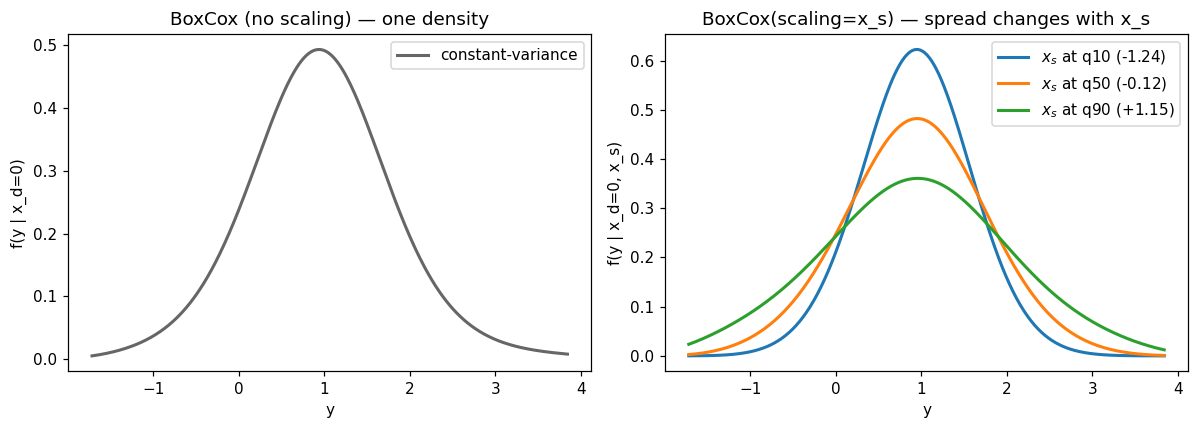

In [6]:
y_grid = np.linspace(a + 0.05, b - 0.05, 400)
xs_q = np.quantile(x_s.ravel(), [0.1, 0.5, 0.9])
colors = ["C0", "C1", "C2"]

fig, (ax_h, ax_f) = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: the constant-variance model — one density for all x_s.
X_zero = np.zeros((y_grid.size, 1))
f_null = null.predict(y_grid, X_new=X_zero, what="density")
ax_h.plot(y_grid, f_null, lw=2, color="0.4", label="constant-variance")
ax_h.set_xlabel("y"); ax_h.set_ylabel("f(y | x_d=0)")
ax_h.set_title("BoxCox (no scaling) — one density")
ax_h.legend()

# Right panel: scaled fit — one density per x_s quantile.
for q, xs_val, c in zip([0.1, 0.5, 0.9], xs_q, colors):
    X_scale = np.full((y_grid.size, 1), xs_val)
    f_full = full.predict(y_grid, X_new=X_zero, X_scale_new=X_scale,
                          what="density")
    ax_f.plot(y_grid, f_full, lw=2, color=c,
              label=f"$x_s$ at q{int(q*100)} ({xs_val:+.2f})")
ax_f.set_xlabel("y"); ax_f.set_ylabel("f(y | x_d=0, x_s)")
ax_f.set_title("BoxCox(scaling=x_s) — spread changes with x_s")
ax_f.legend()
fig.tight_layout();

## 2. Non-proportional Cox survival

Now we move to right-censored survival data.  The scaled-baseline
Cox model is

$$\log\bigl[-\log S(t \mid x_d, x_s)\bigr]
    \;=\; h_0(t)\, e^{0.5\, x_s\gamma} \;+\; x_d\,\beta,$$

i.e. the log-cumulative-hazard contribution of the baseline is
*scaled* by $e^{0.5 x_s\gamma}$.  When $\gamma \neq 0$ the
proportional-hazards assumption fails: survival curves at different
$x_s$ values no longer differ by a constant vertical shift on the
log-log scale, and can spread or cross.

We simulate from this model directly (so the fit can recover the
non-PH structure) and visualise the resulting curves at three
$x_s$ quantiles.

In [7]:
n_cox = 500
x_d_cox = rng.normal(size=n_cox)
x_s_cox = rng.normal(size=n_cox)
beta_true, gamma_true = -0.5, 1.2  # truth on the mltpy scale

# Direct inversion from the min-EV link:
#   S(t|x) = exp(-exp(h_0(t) * exp(0.5*x_s*γ) + x_d*β))
#   ⇒ Z = log(-log(1 - U)) ~ Gumbel_min
#   ⇒ h_0(T) = (Z - x_d*β) / exp(0.5*x_s*γ)
# Picking h_0(t) = log(t) gives an exponential-baseline Cox model
# whose shape is *modulated* by x_s.
U = rng.uniform(1e-5, 1 - 1e-5, size=n_cox)
Z = np.log(-np.log(1 - U))
h_target = (Z - x_d_cox * beta_true) / np.exp(0.5 * x_s_cox * gamma_true)
t = np.exp(h_target)

# Independent exponential censoring + a hard upper cap at b_max
# (treat clipped observations as right-censored).
cens = rng.exponential(scale=4.0, size=n_cox)
y_obs = np.minimum(t, cens)
event = (t <= cens).astype(int)
b_max = 8.0
y_obs = np.clip(y_obs, 1.1e-3, b_max - 1e-4)
event = np.where((t <= cens) & (t <= b_max), event, 0)
print(f"n={n_cox}, censoring={1 - event.mean():.1%}, "
      f"y in [{y_obs.min():.4f}, {y_obs.max():.3f}]")

a_cox, b_cox = 1e-3, b_max
cdata = CensoredData.right_censored(y_obs, (event == 0))

n=500, censoring=22.4%, y in [0.0011, 8.000]


### Proportional-hazards baseline

A standard `Coxph` with `x_d` as the only covariate — the textbook
Cox proportional-hazards model with a smooth Bernstein baseline
$h_0(t)$.  The shape of the implied survival curve does not depend
on $x_s$.

In [8]:
ph = mltpy.Coxph(support=(a_cox, b_cox), order=6).fit(
    cdata, X=x_d_cox.reshape(-1, 1)
)
print(ph.summary())

Model:        Coxph
Support:      (0.001, 8.0)
Basis order:  6
Fitted:       Yes
Log-lik:      -515.9835
AIC:          1047.9671
BIC:          1081.6839
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -0.4142      0.0520    -7.963  1.673e-15


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_58254/3355775036.py:1: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  ph = mltpy.Coxph(support=(a_cox, b_cox), order=6).fit(


### Non-proportional fit via `scaling=`

`Coxph(..., scaling=x_s)` adds the $\gamma$ block; the baseline
$h_0(t)$ is multiplied by $e^{0.5 x_s\gamma}$ per observation, which
scales the log-cumulative hazard non-proportionally.

In [9]:
np_cox = mltpy.Coxph(
    support=(a_cox, b_cox), order=6, scaling=x_s_cox.reshape(-1, 1)
).fit(cdata, X=x_d_cox.reshape(-1, 1))
print(np_cox.summary())
print(f"\ngamma_ (estimate vs truth γ={gamma_true}): {np_cox.gamma_}")

Model:        Coxph
Support:      (0.001, 8.0)
Basis order:  6
Fitted:       Yes
Log-lik:      -476.3271
AIC:          970.6542
BIC:          1008.5856
Converged:    No
n_restarts:   3

Coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1       -0.4551      0.0526    -8.648  5.246e-18
Scaling coefficients:
          Estimate  Std. Error   z value   Pr(>|z|)
  X1        0.6872      0.0818     8.404  4.313e-17

gamma_ (estimate vs truth γ=1.2): [0.68716102]


/var/folders/l3/9xz3dcxx2879v30qp8ptbjbw0000gn/T/ipykernel_58254/3556713684.py:3: ConvergenceWarning: Optimization did not converge after 3 restarts. Solver message: Maximum outer iterations reached without convergence.. The result is the best found, but may not be the MLE.
  ).fit(cdata, X=x_d_cox.reshape(-1, 1))


### Likelihood-ratio test against PH

Same deviance recipe as Example 1: $2(\ell_{\text{np}} - \ell_{\text{ph}})$
against a $\chi^2_{q_s}$ reference.

In [10]:
ll_ph = ph.result_.log_likelihood
ll_np = np_cox.result_.log_likelihood
df = np_cox.n_free_params_ - ph.n_free_params_
lr_stat = 2.0 * (ll_np - ll_ph)
p_value = float(chi2.sf(lr_stat, df=df))
print(f"log-lik PH      : {ll_ph:.3f}  (k={ph.n_free_params_})")
print(f"log-lik non-PH  : {ll_np:.3f}  (k={np_cox.n_free_params_})")
print(f"LR statistic    : {lr_stat:.2f} on {df} df,   p = {p_value:.3g}")

log-lik PH      : -515.984  (k=8)
log-lik non-PH  : -476.327  (k=9)
LR statistic    : 79.31 on 1 df,   p = 5.3e-19


### Spreading and crossing survival curves

We evaluate $S(t \mid x_d=0, x_s)$ over a fine $t$-grid at the
10th, 50th, and 90th percentiles of $x_s$.  Under PH the three
curves would differ only by a constant vertical shift on the
$\log[-\log S]$ scale; under the scaled-baseline fit they spread
as $t$ grows and cross near the median follow-up — the canonical
non-PH signature.

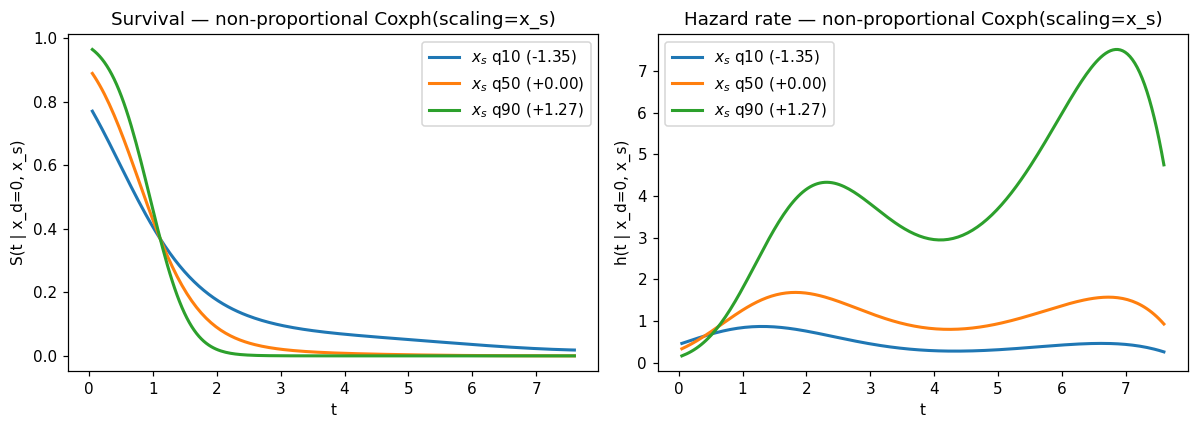

In [11]:
t_grid = np.linspace(0.05, b_cox * 0.95, 200)
xs_q_cox = np.quantile(x_s_cox, [0.1, 0.5, 0.9])
colors = ["C0", "C1", "C2"]

fig, (ax_s, ax_h) = plt.subplots(1, 2, figsize=(11, 4))
X_zero = np.zeros((t_grid.size, 1))

for q, xs_val, c in zip([0.1, 0.5, 0.9], xs_q_cox, colors):
    X_scale = np.full((t_grid.size, 1), xs_val)
    S_np = np_cox.survival(t_grid, X=X_zero, X_scale=X_scale)
    h_np = np_cox.hazard(t_grid, X=X_zero, X_scale=X_scale)
    ax_s.plot(t_grid, S_np, lw=2, color=c,
              label=f"$x_s$ q{int(q*100)} ({xs_val:+.2f})")
    ax_h.plot(t_grid, h_np, lw=2, color=c,
              label=f"$x_s$ q{int(q*100)} ({xs_val:+.2f})")

ax_s.set_xlabel("t"); ax_s.set_ylabel("S(t | x_d=0, x_s)")
ax_s.set_title("Survival — non-proportional Coxph(scaling=x_s)")
ax_s.legend()
ax_h.set_xlabel("t"); ax_h.set_ylabel("h(t | x_d=0, x_s)")
ax_h.set_title("Hazard rate — non-proportional Coxph(scaling=x_s)")
ax_h.legend()
fig.tight_layout();

## Takeaways

- The `scaling=` kwarg on `BoxCox` / `Coxph` / `Colr` / `Lm` / `Survreg`
  mirrors R `tram::*(scale = ~x_s)` and multiplies the baseline by
  $e^{0.5 x_s \gamma}$.  γ is unconstrained — monotonicity in $y$ is
  inherited from $h_0$ because the scaling factor is strictly
  positive (ADR 0002, Decision 3).
- The fitted model exposes `gamma_` and `feature_names_scaling_`;
  `summary()` adds a *Scaling coefficients* block with Wald
  standard errors and p-values for $\gamma$.
- Sign convention is *identical* to R for $\gamma$ — no flip when
  porting `tram` fits.  (β is still negated; the `summary()`
  tabulation handles that for you.)
- `predict(...)` and the convenience methods `survival(...)` /
  `hazard(...)` take an extra `X_scale_new=` / `X_scale=` argument
  on scaled fits.
- Likelihood-ratio tests on $\gamma$ work the same way they do for
  any nested-model comparison: deviance $2\Delta\ell$ on $q_s$ df.
- Combining `scaling=` with `interacting=` (tensor-product baseline)
  is out of scope for v0.4 and raises `ValueError`; if you need
  *and* shape-on-y and *and* spread-on-x, fit them as two separate
  models and compare via deviance.  See
  [04_interacting_terms](04_interacting_terms.ipynb) for the
  tensor-product route on its own.